# Data Engineering Project – Part 1
## BreadCrumb Data Pipeline

This notebook documents your team's implementation of Part 1 of the Data Engineering project. You will use this notebook to record your code, configurations, evidence of a working pipeline, statistics from pipeline runs, and written reflections.

**Instructions:** Work through each section in order. Fill in every cell marked with `[YOUR INPUT HERE]` or `[PASTE HERE]`. Do not delete any section headings or instruction cells.

Submit your results as soon as you have two consecutive days of data successfully processed by your pipeline. Submitting earlier gives you time to revise before the due date if needed.

---

### Team Information

Fill in the cell below with your team details.

**Team Members** (list each member's name and @pdx.edu email, one per line):

Neha Marlady nmarlady@pdx.edu

Vinodh Raju vinodh@pdx.edu

**GCP Project ID:**

cs536-data-engineering

**Vehicle Group Name:**

Shazam

---
## Table of Contents

1. [System Provisioning](#1-system-provisioning)
2. [Python Programs](#2-python-programs)
    - 2.1 [publisher.py](#21-publisherpy)
    - 2.2 [analysis.py](#22-analysispy)
    - 2.3 [backup.py](#23-backuppy)
3. [Automation Configuration](#3-automation-configuration)
    - 3.1 [Publisher VM – Cron Job](#31-publisher-vm--cron-job)
    - 3.2 [Analysis VM – systemd Service](#32-analysis-vm--systemd-service)
    - 3.3 [Backup VM – systemd Service](#33-backup-vm--systemd-service)
    - 3.4 [VM Start/Stop Scheduling](#34-vm-startstop-scheduling)
4. [Evidence of Correct Configuration](#4-evidence-of-correct-configuration)
5. [Pipeline Run Statistics](#5-pipeline-run-statistics)
6. [Reflections](#6-reflections)

---
## 1. System Provisioning

This section documents how you provisioned your GCP infrastructure, including Pub/Sub resources, virtual machines, and multi-student access.

### 1.1 Pub/Sub Topic and Subscriptions

You must create the following Pub/Sub resources in your GCP project:

| Resource | Name | Type |
|---|---|---|
| Topic | `bc_topic` | Pub/Sub Topic |
| Subscription | `analysis_sub` | Pull subscription on `bc_topic` |
| Subscription | `backup_sub` | Pull subscription on `bc_topic` |

Follow the steps that you used in your Data Transport lab to create these resources.


### 1.2 Virtual Machines

Create three VMs with the following specifications:

| VM | Purpose | GCP Region |
|---|---|---|
| Publisher VM | Fetches BreadCrumb data from the BusData server and publishes to `bc_topic` | `us-west1` (Oregon) |
| Analysis VM | Subscribes to `bc_topic` via `analysis_sub` and summarizes received data | `europe-west1` (Belgium) |
| Backup VM | Subscribes to `bc_topic` via `backup_sub`, compresses data, and writes to file | `asia-east1` (Taiwan) |

Use an **e2-medium** machine type and the **Debian 11** (or later) OS image unless you have a specific reason to differ. Ensure each VM has the **Cloud Pub/Sub** API scope enabled (or use a service account with the Pub/Sub Editor role).

**Setting the timezone to Pacific Daylight Time on each VM:**

After SSH-ing into each VM, run the following command so that log timestamps are consistent across all three VMs:

```bash
sudo timedatectl set-timezone America/Los_Angeles
```

Verify the change with:

```bash
timedatectl
```

### 1.3 Configuring Multi-Student Access to a Single GCP Project

Because your team may have up to four members, you should configure GCP so that every team member can work in the same project. **One team member creates the project and then grants IAM roles to the others.**

**Steps:**

1. The project owner navigates to **IAM & Admin > IAM** in the GCP Console.
2. Click **Grant Access** (or **Add Principal**).
3. Enter a teammate's `@pdx.edu` Google account email in the **New principals** field.
4. Assign the role **Editor** (or a more specific set of roles such as Pub/Sub Editor + Compute Instance Admin if you prefer least-privilege).
5. Click **Save**. Repeat for each additional team member.

Each team member must redeem their GCP Education Credit coupon and then switch to the shared project using the project selector in the GCP Console.

> **Note:** Only one team member should redeem their coupon and associate it with the shared project. Other members participate via IAM access and do not need to apply their own coupons to the same project, though they still need to use their coupons for their own lab assignments.

---
## 2. Python Programs

Paste the final version of each of your three Python programs into the corresponding cell below. Each program must be complete and self-contained as it will appear on the VM.

The subsections below describe what each program must do. **You are responsible for writing the code.** Read the requirements carefully before you begin. Feel free to use the similar python programs used in the Data Transport lab, but be sure to update each program to satisfy the requirements.

### 2.1 `publisher.py`

**Requirements for `publisher.py`:**

- Run on the Publisher VM (Oregon).
- Iterate over each of your team's 222 `vehicle_id` values.
- For each `vehicle_id`, make an HTTP GET request to:
  `https://busdata.cs.pdx.edu/api/getBreadCrumbs?vehicle_id=<vehicle_id>`
- Parse the JSON response into individual BreadCrumb records (breadcrumbs).
- Publish each breadcrumb individually to `bc_topic` as a JSON-encoded Pub/Sub message. Do **not** batch all records for a vehicle into a single message.
- Do **not** store all breadcrumbs in memory before publishing. Publish each vehicle's breadcrumbs as soon as you gather them.
- Do **not** write breadcrumbs to the filesystem.
- Keep log output minimal. Do not print every breadcrumb.
- After all vehicle IDs have been processed, publish exactly **one sentinel message** to `bc_topic` to signal that publishing is complete for the day. The sentinel must be distinguishable from a regular BreadCrumb record (for example, use a special key or an empty payload with a known attribute).
- After publishing the sentinel message, log the following statistics:
  - Timestamp of moment when publisher begins accessing getBreadCrumbs API
  - Count of unique `vehicle_id` values for which data was received.
  - Total number of breadcrumbs published.
  - Elapsed wall-clock time for the entire publisher run.
  - Publishing throughput (breadcrumbs per second).
  - Timestamp of moment when publisher sends sentinel message

In [ ]:
# publisher.py
# Paste your publisher.py code here.
import requests
import json
import time
from datetime import datetime
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
TOPIC_ID = "bc_topic"

VEHICLE_IDS = [
    2903, 2905, 2907, 2910, 2914, 2915, 2919, 2920, 2921, 2923,
    2924, 2931, 2933, 2939, 3001, 3007, 3010, 3012, 3014, 3018,
    3020, 3027, 3028, 3037, 3042, 3046, 3054, 3055, 3056, 3059,
    3102, 3107, 3108, 3110, 3112, 3113, 3115, 3118, 3121, 3123,
    3125, 3131, 3137, 3138, 3139, 3142, 3144, 3145, 3146, 3158,
    3162, 3166, 3168, 3170, 3204, 3207, 3208, 3209, 3210, 3214,
    3217, 3219, 3223, 3228, 3230, 3231, 3233, 3239, 3240, 3242,
    3246, 3248, 3249, 3250, 3251, 3252, 3260, 3261, 3265, 3267,
    3301, 3304, 3308, 3312, 3315, 3317, 3322, 3326, 3329, 3330,
    3407, 3408, 3412, 3414, 3418, 3505, 3507, 3513, 3518, 3519,
    3521, 3524, 3528, 3529, 3535, 3536, 3545, 3548, 3551, 3552,
    3554, 3561, 3563, 3566, 3568, 3569, 3572, 3576, 3605, 3606,
    3607, 3610, 3611, 3614, 3620, 3621, 3623, 3628, 3631, 3637,
    3647, 3648, 3649, 3702, 3708, 3715, 3716, 3717, 3718, 3719,
    3721, 3724, 3725, 3728, 3730, 3733, 3737, 3739, 3742, 3743,
    3745, 3751, 3755, 3756, 3902, 3909, 3912, 3913, 3915, 3919,
    3925, 3928, 3932, 3935, 3936, 3939, 3940, 3942, 3943, 3950,
    3959, 3962, 3963, 4003, 4006, 4009, 4010, 4021, 4023, 4025,
    4033, 4036, 4042, 4045, 4046, 4050, 4053, 4055, 4059, 4060,
    4066, 4067, 4069, 4070, 4203, 4211, 4213, 4217, 4218, 4219,
    4221, 4222, 4224, 4234, 4239, 4302, 4303, 4304, 4305, 4502,
    4504, 4505, 4511, 4513, 4516, 4517, 4518, 4520, 4522, 4528,
    4530, 4531,
]

def main():
    publisher = pubsub_v1.PublisherClient()
    topic_path = publisher.topic_path(PROJECT_ID, TOPIC_ID)

    # Capture begin timestamp but don't print yet
    begin_ts = datetime.now()

    total_breadcrumbs = 0
    vehicles_with_data = set()

    for vehicle_id in VEHICLE_IDS:
        url = f"https://busdata.cs.pdx.edu/api/getBreadCrumbs?vehicle_id={vehicle_id}"
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            records = resp.json()
        except Exception as e:
            print(f"WARNING: Could not fetch vehicle {vehicle_id}: {e}")
            continue

        if not records:
            continue

        vehicles_with_data.add(vehicle_id)

        futures = []
        for record in records:
            msg = json.dumps(record).encode("utf-8")
            future = publisher.publish(topic_path, msg)
            futures.append(future)
            total_breadcrumbs += 1

        for f in futures:
            f.result()

    # Wait 5 seconds before sending sentinel
    time.sleep(5)

    # Send sentinel
    sentinel = json.dumps({"sentinel": True}).encode("utf-8")
    publisher.publish(topic_path, sentinel, sentinel="true").result()
    end_ts = datetime.now()

    # Print ALL stats after sentinel
    elapsed = (end_ts - begin_ts).total_seconds()
    throughput = total_breadcrumbs / elapsed if elapsed > 0 else 0

    print(f"BEGIN_TIMESTAMP: {begin_ts.isoformat()}")
    print(f"NUM_VEHICLES:    {len(vehicles_with_data)}")
    print(f"NUM_BREADCRUMBS: {total_breadcrumbs}")
    print(f"WALLTIME:        {elapsed:.2f}s")
    print(f"THROUGHPUT:      {throughput:.1f} breadcrumbs/sec")
    print(f"END_TIMESTAMP:   {end_ts.isoformat()}")

if __name__ == "__main__":
    main()

### 2.2 `analysis.py`

**Requirements for `analysis.py`:**

- Run continuously on the Analysis VM (Belgium). It must not exit or time out between daily runs.
- Subscribe to `bc_topic` using the `analysis_sub` subscription.
- Pull and process breadcrumbs until the sentinel message is received. Do not store individual breadcrumbs in memory or in the filesystem.
- Compute the statistics shown below over all breadcrumbs for all vehicles.
- Upon receipt of the sentinel, log the following statistics:
  - Timestamp of moment when first breadcrumb of the day is received
  - Count of unique `vehicle_id` values.
  - Earliest and latest breadcrumb timestamps (derived from `OPD_DATE` and `ACT_TIME`).
  - Count of unique trips (unique `EVENT_NO_TRIP` values).
  - Total number of breadcrumbs received.
  - Timestamp of moment when sentinel is received.
  - Elapsed wall-clock time from moment when first breadcrumb of the day is received until moment when the sentinel message is received.
  - Analysis Throughput (breadcrumbs per second)
- After logging statistics, reset all statistics data structures and wait for the next day's breadcrumbs.
- Keep log output minimal – do not print every record.

In [ ]:
# analysis.py
# Paste your analysis.py code here.
import json
import time
from datetime import datetime, timedelta
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "analysis_sub"

DRAIN_SECONDS = 30

def process_day(subscriber, sub_path):
    vehicle_ids = set()
    trip_ids = set()
    total = 0
    min_ts = None
    max_ts = None
    begin_wall = None
    sentinel_wall = None

    while True:
        try:
            response = subscriber.pull(
                request={"subscription": sub_path, "max_messages": 500},
                timeout=10,
            )
        except Exception as e:
            if "504" in str(e) or "Deadline Exceeded" in str(e):
                time.sleep(2)
                continue
            else:
                raise

        if not response.received_messages:
            time.sleep(2)
            continue

        ack_ids = []
        sentinel_found = False

        for msg in response.received_messages:
            ack_ids.append(msg.ack_id)
            data = json.loads(msg.message.data.decode("utf-8"))

            if data.get("sentinel") or \
               msg.message.attributes.get("sentinel") == "true":
                if sentinel_wall is None:
                    sentinel_wall = datetime.now()
                sentinel_found = True
                continue

            if begin_wall is None:
                begin_wall = datetime.now()

            vid = data.get("VEHICLE_ID")
            trip = data.get("EVENT_NO_TRIP")
            opd_date = data.get("OPD_DATE", "")
            act_time = data.get("ACT_TIME", 0)

            if vid is not None:
                vehicle_ids.add(vid)
            if trip is not None:
                trip_ids.add(trip)

            try:
                base = datetime.strptime(opd_date.strip(), "%d%b%Y:%H:%M:%S")
                bc_ts = base + timedelta(seconds=int(act_time))
                if min_ts is None or bc_ts < min_ts:
                    min_ts = bc_ts
                if max_ts is None or bc_ts > max_ts:
                    max_ts = bc_ts
            except Exception:
                pass

            total += 1

        if ack_ids:
            subscriber.acknowledge(
                request={"subscription": sub_path, "ack_ids": ack_ids}
            )

        if sentinel_found:
            # Drain for 30 more seconds to catch late messages
            drain_until = time.time() + DRAIN_SECONDS
            while time.time() < drain_until:
                try:
                    response = subscriber.pull(
                        request={"subscription": sub_path, "max_messages": 500},
                        timeout=10,
                    )
                    if not response.received_messages:
                        break
                    ack_ids = []
                    for msg in response.received_messages:
                        ack_ids.append(msg.ack_id)
                        data = json.loads(msg.message.data.decode("utf-8"))
                        if data.get("sentinel") or \
                           msg.message.attributes.get("sentinel") == "true":
                            continue
                        if begin_wall is None:
                            begin_wall = datetime.now()
                        vid = data.get("VEHICLE_ID")
                        trip = data.get("EVENT_NO_TRIP")
                        opd_date = data.get("OPD_DATE", "")
                        act_time = data.get("ACT_TIME", 0)
                        if vid is not None:
                            vehicle_ids.add(vid)
                        if trip is not None:
                            trip_ids.add(trip)
                        try:
                            base = datetime.strptime(opd_date.strip(), "%d%b%Y:%H:%M:%S")
                            bc_ts = base + timedelta(seconds=int(act_time))
                            if min_ts is None or bc_ts < min_ts:
                                min_ts = bc_ts
                            if max_ts is None or bc_ts > max_ts:
                                max_ts = bc_ts
                        except Exception:
                            pass
                        total += 1
                    if ack_ids:
                        subscriber.acknowledge(
                            request={"subscription": sub_path, "ack_ids": ack_ids}
                        )
                except Exception:
                    break

            # WALLTIME uses sentinel timestamp not after drain
            elapsed = (sentinel_wall - begin_wall).total_seconds() if begin_wall else 0
            throughput = total / elapsed if elapsed > 0 else 0

            print(f"BEGIN_TIMESTAMP:  {begin_wall.isoformat() if begin_wall else 'N/A'}")
            print(f"NUM_VEHICLES:     {len(vehicle_ids)}")
            print(f"MIN_BC_TIMESTAMP: {min_ts}")
            print(f"MAX_BC_TIMESTAMP: {max_ts}")
            print(f"NUM_TRIPS:        {len(trip_ids)}")
            print(f"NUM_BREADCRUMBS:  {total}")
            print(f"END_TIMESTAMP:    {sentinel_wall.isoformat()}")
            print(f"WALLTIME:         {elapsed:.2f}s")
            print(f"THROUGHPUT:       {throughput:.1f} breadcrumbs/sec")
            return

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)

    print("analysis.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next day's data...")
        except Exception as e:
            if "504" in str(e) or "Deadline Exceeded" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} — retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()

### 2.3 `backup.py`

**Requirements for `backup.py`:**

- Run continuously on the Backup VM (Taiwan). It must not exit or time out between daily runs.
- Subscribe to `bc_topic` using the `backup_sub` subscription.
- Pull and process breadcrumbs until the sentinel message is received.
  - Write breadcrumbs to a daily backup file (named `breadcrumbs_<DATE>_.log`)
  - Compute the statistics listed below
- Upon receipt of the sentinel, close the backup file, note its size, and compress it.  
- Then log the following statistics:
  - Timestamp of moment when first breadcrumb of the day is received
  - Total number of breadcrumbs received.
  - Number of bytes received (the size of the backup file prior to compression)
  - Count of unique `vehicle_id` values.
  - Timestamp of moment when the backup file is compressed
  - Elapsed wall-clock time from moment when first breadcrumb of the day is received until moment when backup file is compressed.
  - Throughput (number of breadcrumbs divided by elapsed wall-clock time)
- After logging statistics, reset all statistics data structures and wait for the next day's breadcrumbs.
- Keep log output minimal – do not print every record.

In [ ]:
# backup.py
# Paste your backup.py code here.
import json
import gzip
import os
import time
from datetime import datetime
from google.cloud import pubsub_v1

PROJECT_ID = "cs536-data-engineering"
SUBSCRIPTION_ID = "backup_sub"
BACKUP_DIR = "/home/vinodh"

DRAIN_SECONDS = 30

def process_day(subscriber, sub_path):
    today = datetime.now().strftime("%Y-%m-%d")
    filepath = os.path.join(BACKUP_DIR, f"breadcrumbs_{today}_.log")

    vehicle_ids = set()
    total = 0
    begin_wall = None

    with open(filepath, "w") as f:
        while True:
            try:
                response = subscriber.pull(
                    request={"subscription": sub_path, "max_messages": 500},
                    timeout=10,
                )
            except Exception as e:
                if "504" in str(e) or "Deadline Exceeded" in str(e):
                    time.sleep(2)
                    continue
                else:
                    raise

            if not response.received_messages:
                time.sleep(2)
                continue

            ack_ids = []
            sentinel_found = False

            for msg in response.received_messages:
                ack_ids.append(msg.ack_id)
                data = json.loads(msg.message.data.decode("utf-8"))

                if data.get("sentinel") or \
                   msg.message.attributes.get("sentinel") == "true":
                    sentinel_found = True
                    continue

                if begin_wall is None:
                    begin_wall = datetime.now()

                vid = data.get("VEHICLE_ID")
                if vid is not None:
                    vehicle_ids.add(vid)

                f.write(json.dumps(data) + "\n")
                total += 1

            if ack_ids:
                subscriber.acknowledge(
                    request={"subscription": sub_path, "ack_ids": ack_ids}
                )

            if sentinel_found:
                # Drain for 30 more seconds to catch late messages
                drain_until = time.time() + DRAIN_SECONDS
                while time.time() < drain_until:
                    try:
                        response = subscriber.pull(
                            request={"subscription": sub_path, "max_messages": 500},
                            timeout=10,
                        )
                        if not response.received_messages:
                            break
                        ack_ids = []
                        for msg in response.received_messages:
                            ack_ids.append(msg.ack_id)
                            data = json.loads(msg.message.data.decode("utf-8"))
                            if data.get("sentinel") or \
                               msg.message.attributes.get("sentinel") == "true":
                                continue
                            if begin_wall is None:
                                begin_wall = datetime.now()
                            vid = data.get("VEHICLE_ID")
                            if vid is not None:
                                vehicle_ids.add(vid)
                            f.write(json.dumps(data) + "\n")
                            total += 1
                        if ack_ids:
                            subscriber.acknowledge(
                                request={"subscription": sub_path, "ack_ids": ack_ids}
                            )
                    except Exception:
                        break

                # Close and compress after drain
                f.flush()
                raw_size = os.path.getsize(filepath)

                gz_path = filepath + ".gz"
                with open(filepath, "rb") as fin, gzip.open(gz_path, "wb") as fout:
                    fout.writelines(fin)
                os.remove(filepath)

                compress_ts = datetime.now()
                elapsed = (compress_ts - begin_wall).total_seconds() if begin_wall else 0
                throughput = total / elapsed if elapsed > 0 else 0

                print(f"BEGIN_TIMESTAMP: {begin_wall.isoformat() if begin_wall else 'N/A'}")
                print(f"NUM_BREADCRUMBS: {total}")
                print(f"DATASIZE:        {raw_size} bytes")
                print(f"NUM_VEHICLES:    {len(vehicle_ids)}")
                print(f"END_TIMESTAMP:   {compress_ts.isoformat()}")
                print(f"WALLTIME:        {elapsed:.2f}s")
                print(f"THROUGHPUT:      {throughput:.1f} breadcrumbs/sec")
                return

def main():
    subscriber = pubsub_v1.SubscriberClient()
    sub_path = subscriber.subscription_path(PROJECT_ID, SUBSCRIPTION_ID)

    print("backup.py started, waiting for data...")
    while True:
        try:
            process_day(subscriber, sub_path)
            print("Day complete. Waiting for next day's data...")
        except Exception as e:
            if "504" in str(e) or "Deadline Exceeded" in str(e):
                time.sleep(10)
            else:
                print(f"Error: {e} — retrying in 10s")
                time.sleep(10)

if __name__ == "__main__":
    main()

---
## 3. Automation Configuration

This section documents how you automated execution of your pipeline programs.

### 3.1 Publisher VM – Cron Job

`publisher.py` is a batch program that runs once per day. You will use a **cron job** to automate it.

**Background – How cron works:**

Cron is a Linux daemon that runs commands on a schedule. Each user has a personal crontab file that lists jobs. You edit your crontab with:

```bash
crontab -e
```

Each line in a crontab follows this format:

```
minute  hour  day_of_month  month  day_of_week  command
```

Fields use `*` to mean "every". For example, to run `publisher.py` at **9:15 AM every day**:

```
15 9 * * * /usr/bin/python3 /home/USERNAME/publisher.py >> /home/USERNAME/publisher.log 2>&1
```

The `>> publisher.log 2>&1` part appends both standard output and standard error to a log file.

**Important:** Your team should choose a **single hour of the day, preferably before noon Pacific Time**, for your pipeline to run. All scheduling (cron job and VM start/stop) must be coordinated around this hour. We run for only one hour per day to conserve GCP credits.

**Schedule your cron job to run within your chosen hour**, allowing enough time for the VM to finish booting before `publisher.py` starts (e.g., if your VMs start at 9:00 AM, schedule the cron job for 9:10 AM).

Verify cron is installed and running on the Publisher VM:

```bash
sudo systemctl status cron
```

**Paste your crontab entry below** (the exact line you added using `crontab -e`):

```
# Edit this file to introduce tasks to be run by cron.
#
# Each task to run has to be defined through a single line
# indicating with different fields when the task will be run
# and what command to run for the task
#
# To define the time you can provide concrete values for
# minute (m), hour (h), day of month (dom), month (mon),
# and day of week (dow) or use '*' in these fields (for 'any').
#
# Notice that tasks will be started based on the cron's system
# daemon's notion of time and timezones.
#
# Output of the crontab jobs (including errors) is sent through
# email to the user the crontab file belongs to (unless redirected).
#
# For example, you can run a backup of all your user accounts
# at 5 a.m every week with:
# 0 5 * * 1 tar -zcf /var/backups/home.tgz /home/
#
# For more information see the manual pages of crontab(5) and cron(8)
#
# m h  dom mon dow   command
0 8 * * * /usr/bin/python3 /home/nmarlady/publisher.py >> /home/nmarlady/publisher.log 2>&1


```

### 3.2 Analysis VM – systemd Service

`analysis.py` must run **continuously** – it cannot be managed by cron, which only starts programs on a schedule. Instead, use a **systemd service**, which starts a program at boot and restarts it automatically if it crashes.

**Background – How systemd services work:**

A systemd service is defined by a unit file placed in `/etc/systemd/system/`. Here is an example unit file for `analysis.py`:

```ini
[Unit]
Description=BreadCrumb Analysis Service
After=network.target

[Service]
Type=simple
User=nmarlady
WorkingDirectory=/home/nmarlady
ExecStart=/usr/bin/python3 -u /home/nmarlady/analysis.py
Restart=always
RestartSec=10
StandardOutput=append:/home/nmarlady/analysis.log
StandardError=append:/home/nmarlady/analysis.log

[Install]
WantedBy=multi-user.target
```

Replace `USERNAME` with your Linux username on the VM.

**Steps to install and enable the service:**

```bash
# Copy the unit file to the systemd directory
sudo cp analysis.service /etc/systemd/system/analysis.service

# Reload systemd so it sees the new unit file
sudo systemctl daemon-reload

# Enable the service to start at boot
sudo systemctl enable analysis.service

# Start it immediately
sudo systemctl start analysis.service

# Check its status
sudo systemctl status analysis.service
```

**Paste the contents of your `analysis.service` unit file below:**

```int
[Unit]
Description=BreadCrumb Analysis Service
After=network.target

[Service]
Type=simple
User=vinodh
WorkingDirectory=/home/vinodh
ExecStart=/usr/bin/python3 /home/vinodh/analysis.py
Restart=always
RestartSec=10
StandardOutput=append:/home/vinodh/analysis.log
StandardError=append:/home/vinodh/analysis.log

[Install]
WantedBy=multi-user.target```


### 3.3 Backup VM – systemd Service

`backup.py` must also run continuously, so it is automated in the same way as `analysis.py`. Create a systemd unit file named `backup.service` on the Backup VM following the same pattern shown in Section 3.2, substituting `backup.py` and appropriate description text.

**Paste the contents of your `backup.service` unit file below:**

```ini
[Unit]
Description=BreadCrumb Backup Service
After=network.target

[Service]
Type=simple
User=nmarlady
WorkingDirectory=/home/nmarlady
ExecStart=/usr/bin/python3 /home/nmarlady/backup.py
Restart=always
RestartSec=10
StandardOutput=append:/home/nmarlady/backup.log
StandardError=append:/home/nmarlady/backup.log

[Install]
WantedBy=multi-user.target```

### 3.4 VM Start/Stop Scheduling

To conserve GCP credits, your VMs should be running for **only one hour per day** – the hour during which your pipeline executes. GCP provides a built-in **Instance Schedule** feature to automate VM start and stop.

**Steps to create an instance schedule:**

1. In the GCP Console, navigate to **Compute Engine > Instance Schedules** (under the "Virtual machines" section in the left-hand menu, or search for it).
2. Click **Create Schedule**.
3. Give the schedule a name (e.g., `pipeline-daily-schedule`).
4. Set the **region** to match one of your VMs (you may need a schedule per region, or you can use a global approach via Cloud Scheduler – see the note below).
5. Configure the **start time** to be at the beginning of your chosen hour (e.g., `09:00`) and the **stop time** to be one hour later (e.g., `10:00`).
6. Set the **time zone** to `America/Los_Angeles`.
7. Save the schedule, then **attach it** to each of your three VMs from the VM's detail page under **Availability policies**.

**Describe your VM scheduling configuration below.** Include:
- Your chosen daily execution hour (in Pacific Time)
- The names of the schedules you created
- The start and stop times configured for each VM

12:00AM to 1:00AM

publish-schedule
backup-schedule
analysis-schedule

12:00AM to 1:00AM, all time zone America/Los_Angeles



---
## 4. Evidence of Correct Configuration

Provide screenshots or gcloud CLI output demonstrating that each component of your infrastructure has been correctly provisioned and configured. Paste images or text output into the cells below.

Required evidence items:

| # | Item |
|---|---|
| 4.1 | Pub/Sub topic `bc_topic` exists |
| 4.2 | Subscriptions `analysis_sub` and `backup_sub` exist and are attached to `bc_topic` |
| 4.3 | Publisher VM exists in Oregon region |
| 4.4 | Analysis VM exists in Belgium region |
| 4.5 | Backup VM exists in Taiwan region |
| 4.6 | All three VMs have Pacific time zone set (`timedatectl` output) |
| 4.7 | `analysis.service` is enabled and running on the Analysis VM |
| 4.8 | `backup.service` is enabled and running on the Backup VM |
| 4.9 | VM start/stop schedules are attached to all three VMs |
| 4.10 | IAM configuration showing all team members have access to the project |


### 4.1 – Pub/Sub topic `bc_topic`
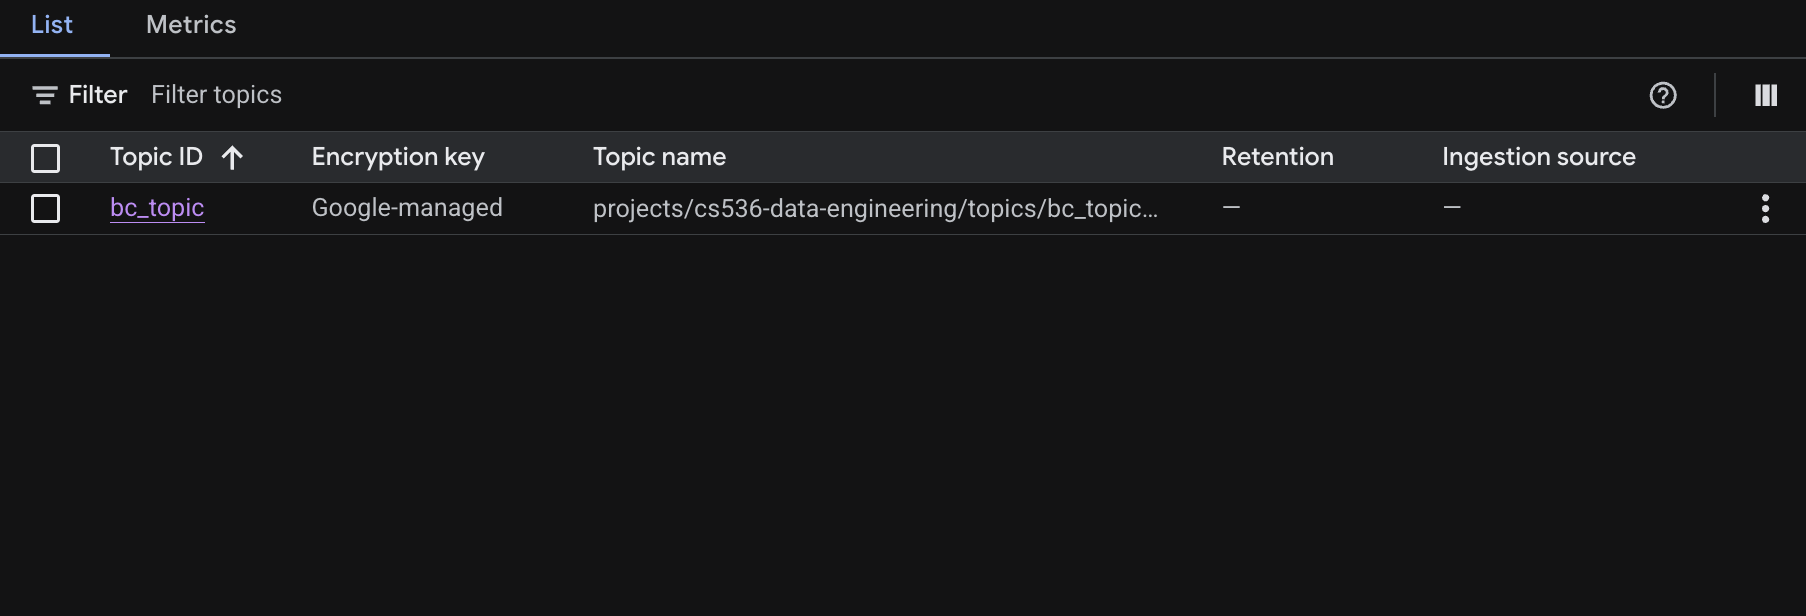

### 4.2 – Subscriptions `analysis_sub` and `backup_sub`

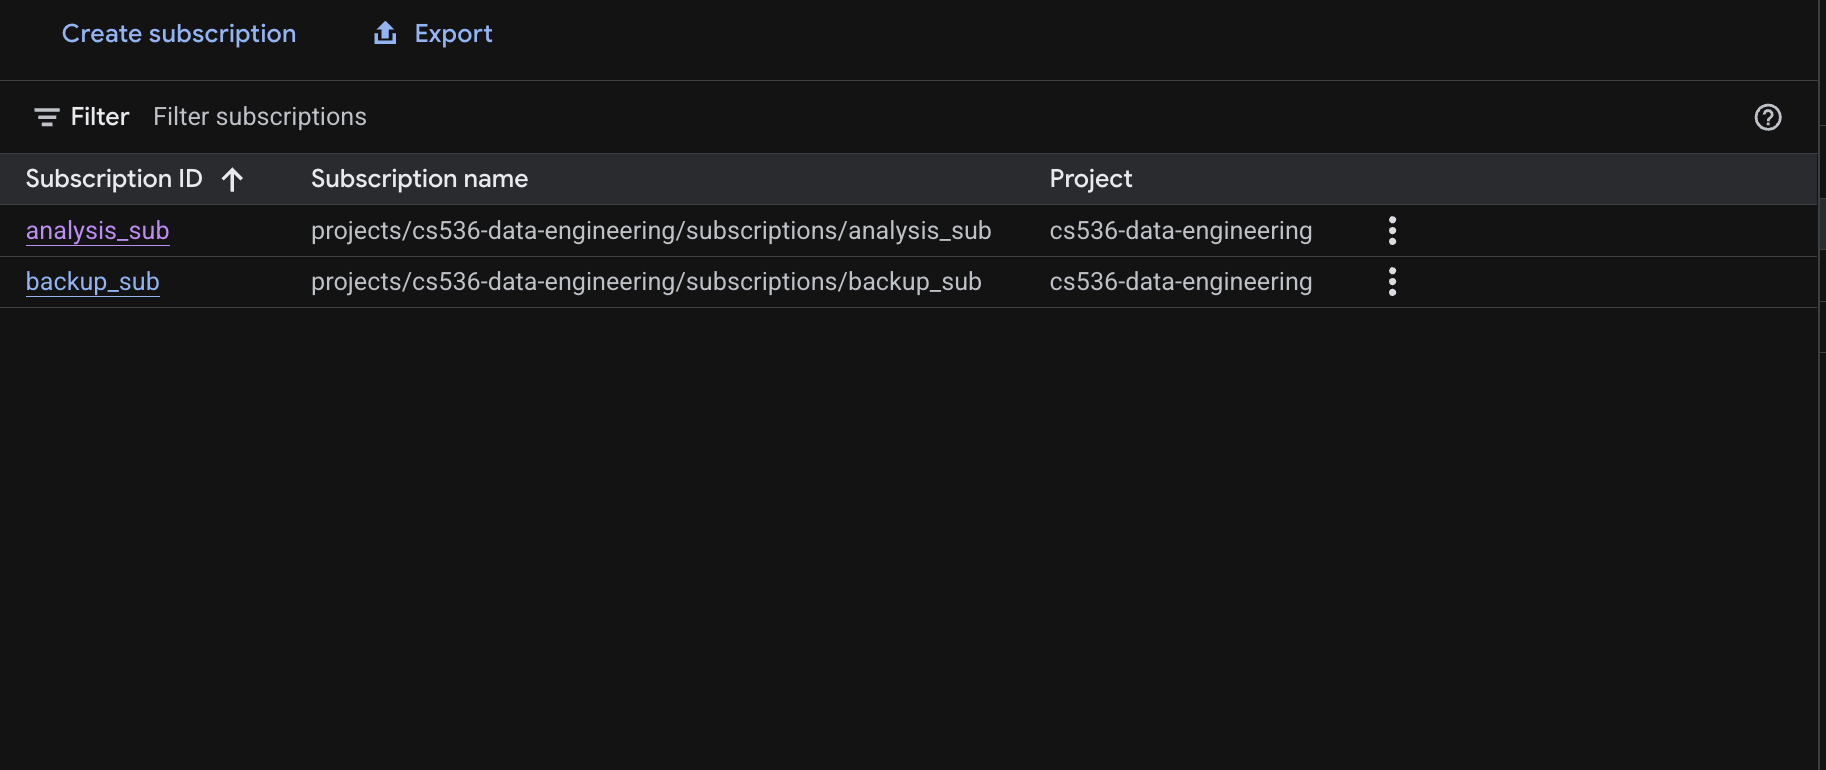

### 4.3 – Publisher VM (Oregon)

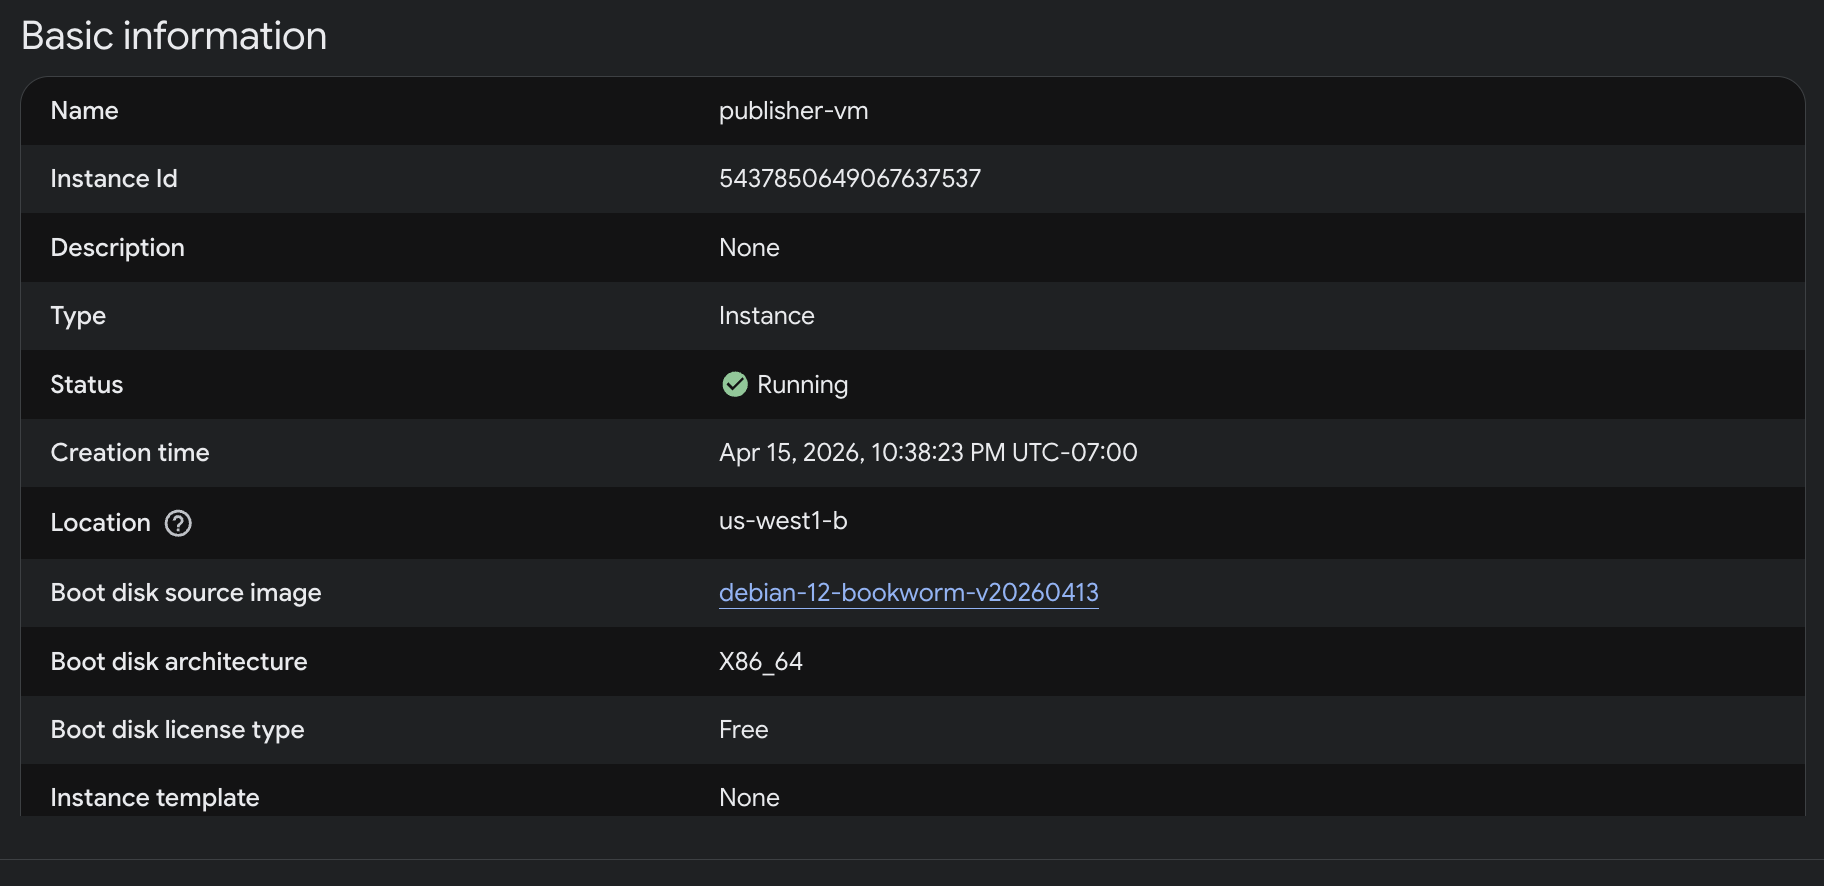

### 4.4 – Analysis VM (Belgium)

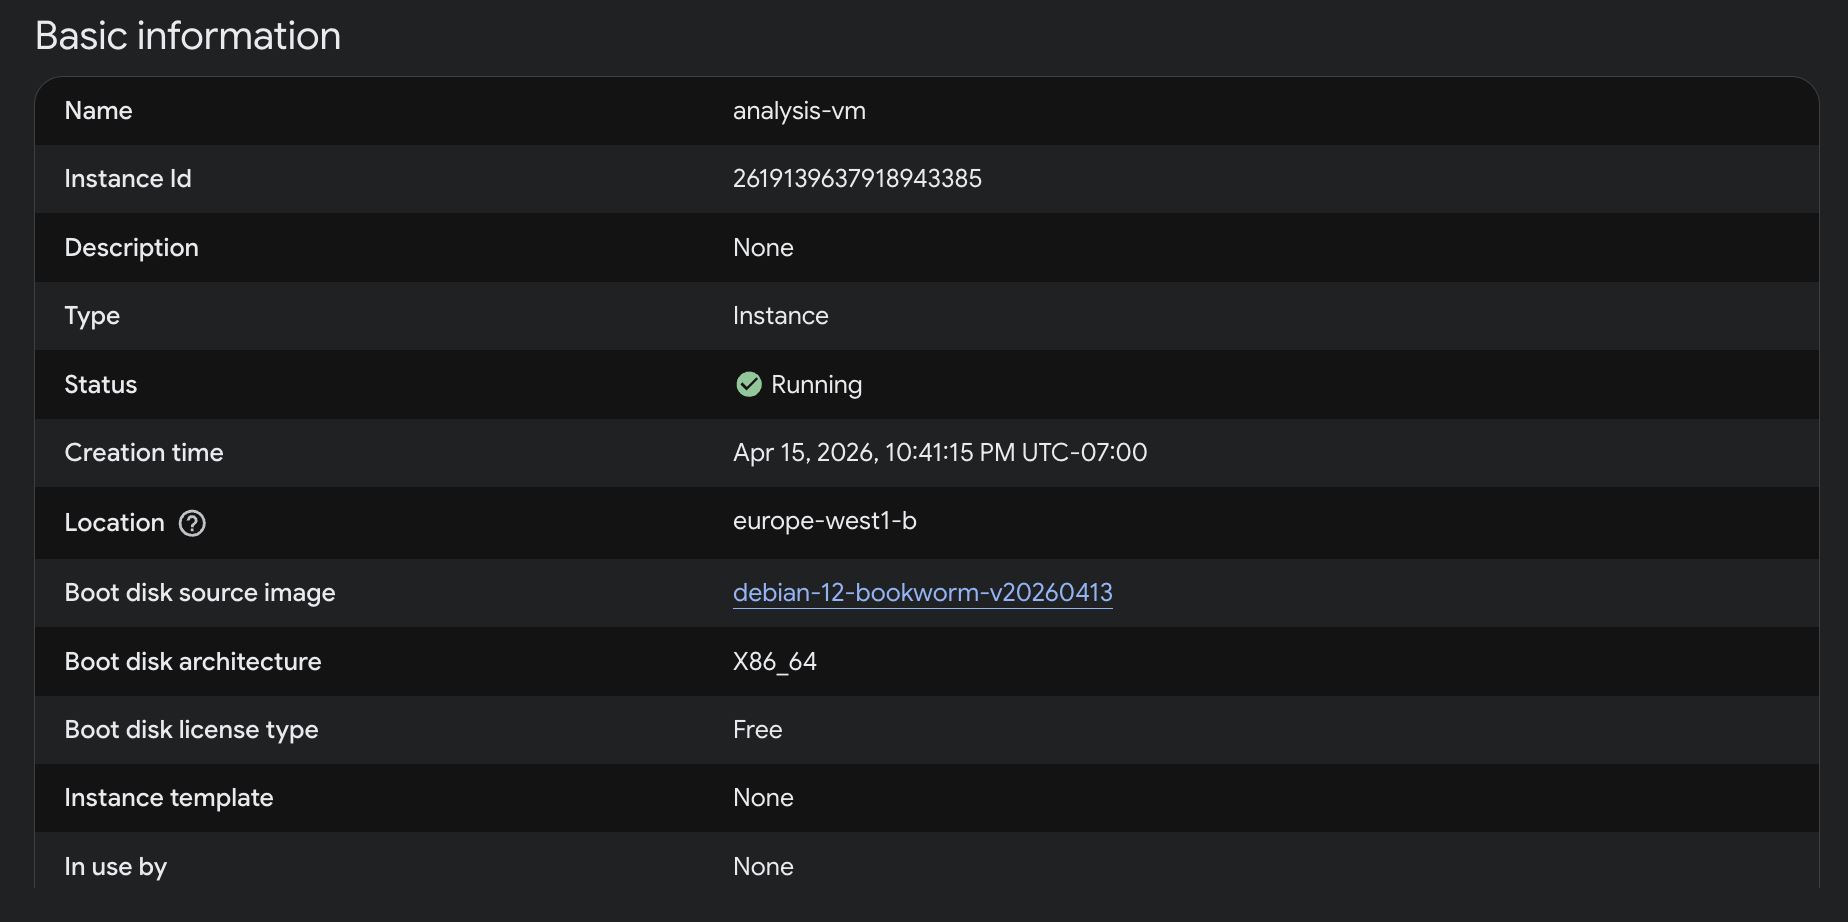

### 4.5 – Backup VM (Taiwan)

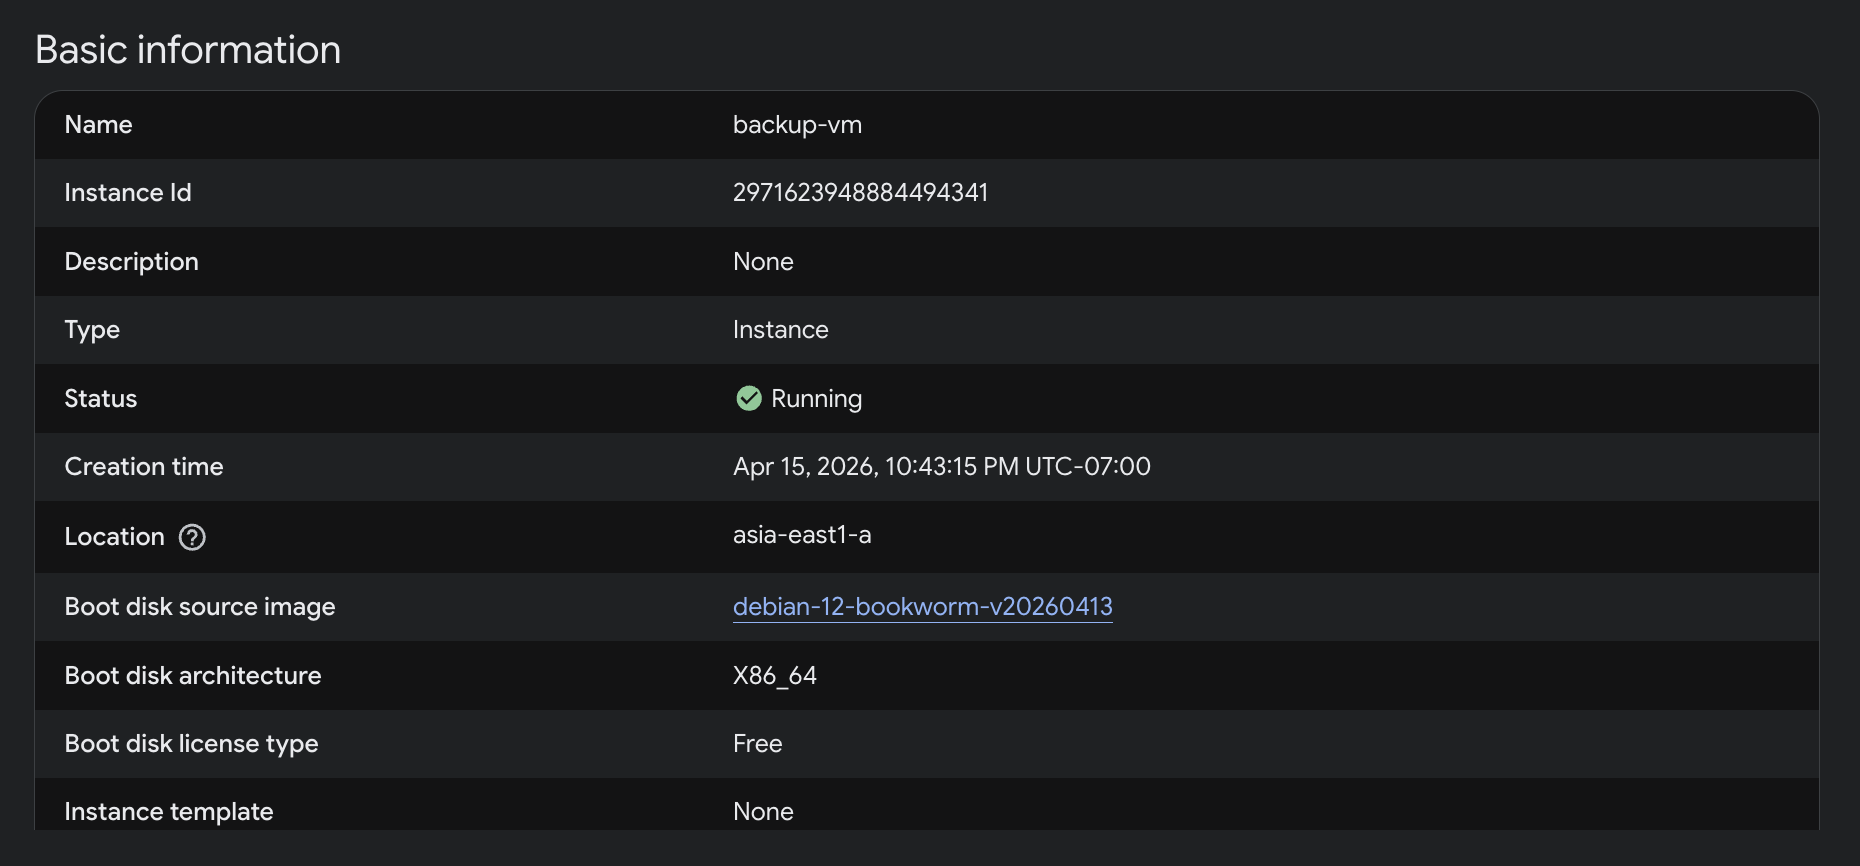

### 4.6 – Pacific Time Zone on All VMs (`timedatectl` output)

**Publisher VM:**
```
nmarlady@publisher-vm:~$ timedatectl
               Local time: Fri 2026-04-17 18:20:51 PDT
           Universal time: Sat 2026-04-18 01:20:51 UTC
                 RTC time: Sat 2026-04-18 01:20:51
                Time zone: America/Los_Angeles (PDT, -0700)
System clock synchronized: yes
              NTP service: active
          RTC in local TZ: no```

**Analysis VM:**
```
nmarlady@analysis-vm:~$ timedatectl
               Local time: Fri 2026-04-17 18:20:58 PDT
           Universal time: Sat 2026-04-18 01:20:58 UTC
                 RTC time: Sat 2026-04-18 01:20:58
                Time zone: America/Los_Angeles (PDT, -0700)
System clock synchronized: yes
              NTP service: active
          RTC in local TZ: no
```

**Backup VM:**
```
nmarlady@backup-vm:~$ timedatectl
               Local time: Fri 2026-04-17 18:20:55 PDT
           Universal time: Sat 2026-04-18 01:20:55 UTC
                 RTC time: Sat 2026-04-18 01:20:55
                Time zone: America/Los_Angeles (PDT, -0700)
System clock synchronized: yes
              NTP service: active
          RTC in local TZ: no
```

### 4.7 – `analysis.service` Status

```
[PASTE OUTPUT OF: sudo systemctl status analysis.service]

nmarlady@analysis-vm:~$ sudo systemctl status analysis.service
● analysis.service - BreadCrumb Analysis Service
     Loaded: loaded (/etc/systemd/system/analysis.service; enabled; preset: enabled)
     Active: active (running) since Fri 2026-04-17 17:16:41 PDT; 1h 7min ago
   Main PID: 377 (python3)
      Tasks: 7 (limit: 4682)
     Memory: 90.3M
        CPU: 49.234s
     CGroup: /system.slice/analysis.service
             └─377 /usr/bin/python3 /home/nmarlady/analysis.py

Apr 17 17:16:41 analysis-vm systemd[1]: Started analysis.service - BreadCrumb Analysis Service.
nmarlady@analysis-vm:~$
```

### 4.8 – `backup.service` Status

```
[PASTE OUTPUT OF: sudo systemctl status backup.service]

nmarlady@backup-vm:~$ sudo systemctl status backup.service
● backup.service - BreadCrumb Backup Service
     Loaded: loaded (/etc/systemd/system/backup.service; enabled; preset: enabled)
     Active: active (running) since Fri 2026-04-17 17:16:40 PDT; 1h 8min ago
   Main PID: 383 (python3)
      Tasks: 7 (limit: 4682)
     Memory: 104.6M
        CPU: 56.013s
     CGroup: /system.slice/backup.service
             └─383 /usr/bin/python3 /home/nmarlady/backup.py

Apr 17 17:16:40 backup-vm systemd[1]: Started backup.service - BreadCrumb Backup Service.
nmarlady@backup-vm:~$
```

### 4.9 – VM Start/Stop Schedules

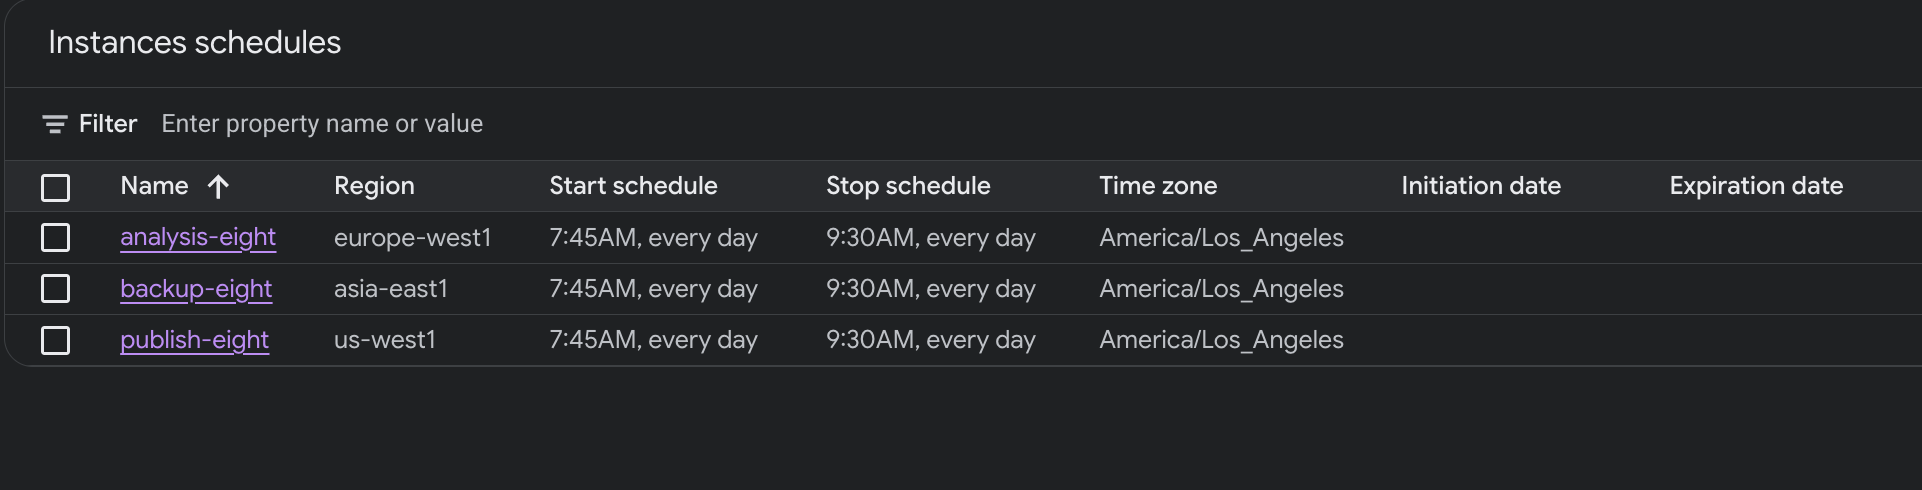


### 4.10 – IAM Configuration (Team Member Access)

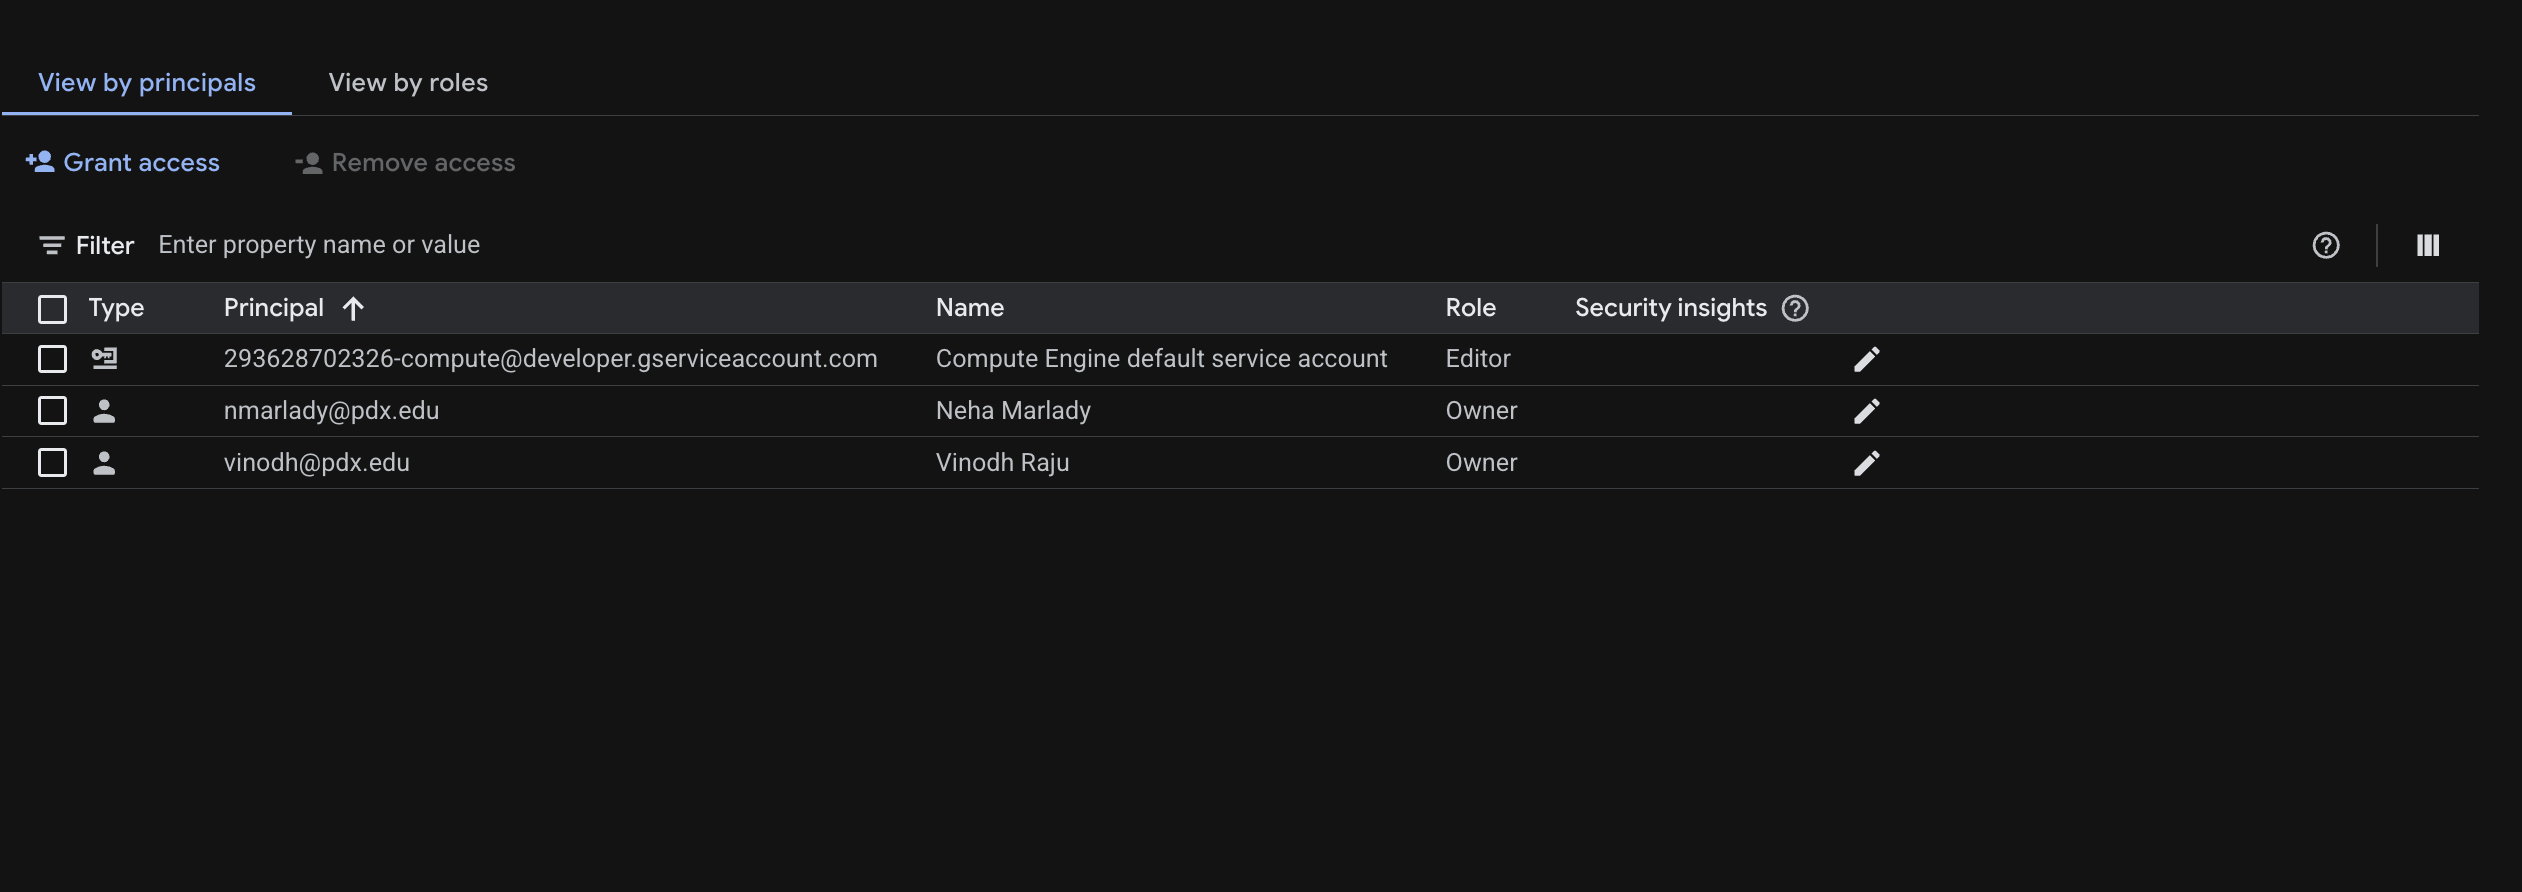

---
## 5. Pipeline Run Statistics

You must demonstrate that your pipeline ran correctly on **at least two consecutive days**. For each day, paste the statistics logged by all three programs.

> **Important:** Your statistics will be compared against known expected values. Ensure your programs compute and report all required statistics accurately. Reasonable tolerance will be applied.

### 5.1 Day 1 Statistics

**Date:**  04-19-2026

#### Day 1 – `publisher.py` Output

```

BEGIN_TIMESTAMP:
NUM_VEHICLES:    153
NUM_BREADCRUMBS: 713716
WALLTIME:        
THROUGHPUT:      
END_TIMESTAMP:   ```

Expected fields:
  - (BEGIN_TIMESTAMP) Timestamp of moment when publisher begins accessing getBreadCrumbs API
  - (NUM_VEHICLES) Count of unique `vehicle_id` values
  - (NUM_BREADCRUMBS) Total number of breadcrumbs published.
  - (WALLTIME) Elapsed wall-clock time for the entire publisher run.
  - (THROUGHPUT) Publishing throughput (breadcrumbs per second).
  - (END_TIMESTAMP) Timestamp of moment when publisher sends sentinel message

#### Day 1 – `analysis.py` Output

```
BEGIN_TIMESTAMP:  2026-04-19T18:34:57.255073
NUM_VEHICLES:     153
MIN_BC_TIMESTAMP: 2022-12-21 04:04:33
MAX_BC_TIMESTAMP: 2022-12-22 02:51:53
NUM_TRIPS:        1766
NUM_BREADCRUMBS:  703488
END_TIMESTAMP:    2026-04-19T18:42:51.232494
WALLTIME:         473.98s
THROUGHPUT:       1484.2 breadcrumbs/sec
Day complete. Waiting for next day's data...```

Expected fields:
  - (BEGIN_TIMESTAMP) Timestamp of moment when first breadcrumb of the day is received
  - (NUM_VEHICLES) Count of unique `vehicle_id` values.
  - (MIN_BC_TIMESTAMP) Earliest breadcrumb timestamp (derived from `OPD_DATE` and `ACT_TIME`).
  - (MAX_BC_TIMESTAMP) Latest breadcrumb timestamp (derived from `OPD_DATE` and `ACT_TIME`).
  - (NUM_TRIPS) Count of unique trips (unique `EVENT_NO_TRIP` values).
  - (NUM_BREADCRUMBS) Total number of breadcrumbs received.
  - (END_TIMESTAMP) Timestamp of moment when sentinel is received.
  - (WALLTIME) Elapsed wall-clock time from moment when first breadcrumb of the day is received until moment when the sentinel message is received.
  - (THROUGHPUT) Analysis Throughput (breadcrumbs per second)


#### Day 1 – `backup.py` Output

```
BEGIN_TIMESTAMP:    2026-04-19T18:34:57.904192
NUM_BREADCRUMBS:    713716
DATASIZE:           174929828 bytes
NUM_VEHICLES:       153
COMPRESS_TIMESTAMP: 2026-04-19T18:41:15.106863
WALLTIME:           377.20s
THROUGHPUT:         1892.1 breadcrumbs/sec
Day complete. Waiting for next day's data...```

Expected fields:
  - (BEGIN_TIMESTAMP) Timestamp of moment when first breadcrumb of the day is received
  - (NUM_BREADCRUMBS) Total number of breadcrumbs received.
  - (DATASIZE) Total bytes received (the size of the backup file prior to compression)
  - (NUM_VEHICLES) Count of unique `vehicle_id` values.
  - (END_TIMESTAMP) Timestamp of moment when the backup file is compressed
  - (WALLTIME) Elapsed wall-clock time from moment when first breadcrumb of the day is received until moment when backup file is compressed.
  - (THROUGHPUT) Throughput (number of breadcrumbs divided by elapsed wall-clock time)

### 5.2 Day 2 Statistics

**Date:**  04-20-2026

#### Day 2 – `publisher.py` Output

```
BEGIN_TIMESTAMP: 2026-04-20T08:00:03.237164
NUM_VEHICLES:    153
NUM_BREADCRUMBS: 728608
WALLTIME:        114.60s
THROUGHPUT:      6357.7 breadcrumbs/sec
END_TIMESTAMP:   2026-04-20T08:01:57.839615
```

#### Day 2 – `analysis.py` Output

```
BEGIN_TIMESTAMP:  2026-04-20T08:00:08.730281
NUM_VEHICLES:     153
MIN_BC_TIMESTAMP: 2022-12-22 03:25:10
MAX_BC_TIMESTAMP: 2022-12-23 03:24:11
NUM_TRIPS:        1807
NUM_BREADCRUMBS:  725850
END_TIMESTAMP:    2026-04-20T08:09:01.218947
WALLTIME:         532.49s
THROUGHPUT:       1363.1 breadcrumbs/sec
Day complete. Waiting for next day's data...```

#### Day 2 – `backup.py` Output

```
backup.py started, waiting for data...
BEGIN_TIMESTAMP:    2026-04-20T08:00:09.626296
NUM_BREADCRUMBS:    728608
DATASIZE:           178604702 bytes
NUM_VEHICLES:       153
COMPRESS_TIMESTAMP: 2026-04-20T08:09:13.569632
WALLTIME:           543.94s
THROUGHPUT:         1339.5 breadcrumbs/sec
Day complete. Waiting for next day's data...```

---
## 6. Reflections

Answer each of the following questions thoughtfully. Write in complete sentences. There is no single correct answer for most of these questions – we are looking for evidence that you have thought carefully about the design of your pipeline.

### 6.1 Implementation Challenge

**What was the most difficult issue that you encountered while implementing your pipeline? How did you resolve it?**

data consistency. made some changes in code, even then facing the issue with analysis log.

### 6.2 Purpose of the Sentinel Message

**Why did we use a sentinel message in the pipeline?**

the sentinel acts as an explicit "end of day" signal that makes the pipeline deterministic and reliable, regardless of how many breadcrumbs were published or how long it took.

### 6.3 Sufficiency of the Sentinel Approach

**Is the sentinel message a sufficient solution for managing a data pipeline? What are its limitations?**

**Is the Sentinel Message a Sufficient Solution?**

The sentinel message works well for this simple pipeline where there is exactly one publisher and two subscribers. However, it has key limitations since Pub/Sub does not guarantee message ordering, the sentinel could arrive before some breadcrumbs, causing subscribers to miss data. It also assumes the publisher completes successfully, if it crashes before sending the sentinel, subscribers will wait indefinitely. Additionally, since Pub/Sub delivers messages at least once, the sentinel itself could be delivered multiple times, potentially triggering the end-of-day logic more than once. For a more robust production pipeline, alternatives like watermarks or ordered message delivery would be more reliable.

### 6.4 Pipeline Correctness

**What problems or issues might affect the correctness of the data pipeline?**

Several issues could affect the correctness of this data pipeline. First, since Pub/Sub guarantees at-least-once delivery, some breadcrumbs may be delivered and processed more than once, leading to inflated counts in analysis and backup. Second, message ordering is not guaranteed, so breadcrumbs from the same vehicle could arrive out of order, affecting timestamp calculations like MIN_BC_TIMESTAMP and MAX_BC_TIMESTAMP. Third, if the BusData API returns incomplete or missing data for some vehicles (as seen with our 404 errors), those vehicles are silently skipped, reducing the total breadcrumb count. Fourth, network latency differences between the three VMs (Oregon, Belgium, Taiwan) mean that subscribers may not receive all messages before the sentinel arrives, causing slight count discrepancies. Finally, if the publisher crashes mid-run, some vehicles' breadcrumbs will never be published and the sentinel will never be sent, leaving subscribers waiting indefinitely with incomplete data.

### 6.5 Multiple Publishers

**The pipeline uses a single publisher. When and why might a data pipeline use multiple publishers?**

A data pipeline might use multiple publishers when the volume of data is too large for a single publisher to handle efficiently in our case, fetching 222 vehicles sequentially takes over 100 seconds, and multiple publishers could split the vehicle IDs and publish in parallel, reducing this significantly. Multiple publishers also provide fault tolerance, so if one crashes the others continue processing their assigned vehicles. However, this introduces the challenge of sentinel coordination, where subscribers must wait for all publishers to send their sentinels before computing final statistics.